# Import necessary dependencies and settings

In [75]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

pd.options.display.max_colwidth = 200
%matplotlib inline

# Sample corpus of text documents

In [77]:
corpus = ['The sky is blue and beautiful.',
          'Love this blue and beautiful sky!',
          'The quick brown fox jumps over the lazy dog.',
          "A king's breakfast has sausages, ham, bacon, eggs, toast and beans",
          'I love green eggs, ham, sausages and bacon!',
          'The brown fox is quick and the blue dog is lazy!',
          'The sky is very blue and the sky is very beautiful today',
          'The dog is lazy but the brown fox is quick!'    
]
labels = ['weather', 'weather', 'animals', 'food', 'food', 'animals', 'weather', 'animals']

corpus = np.array(corpus)
corpus_df = pd.DataFrame({'Document': corpus, 
                          'Category': labels})
corpus_df = corpus_df[['Document', 'Category']]
corpus_df

,Document,Category
0,The sky is blue and beautiful.,weather
1,Love this blue and beautiful sky!,weather
2,The quick brown fox jumps over the lazy dog.,animals
3,"A king's breakfast has sausages, ham, bacon, eggs, toast and beans",food
4,"I love green eggs, ham, sausages and bacon!",food
5,The brown fox is quick and the blue dog is lazy!,animals
6,The sky is very blue and the sky is very beautiful today,weather
7,The dog is lazy but the brown fox is quick!,animals


# Simple text pre-processing

In [79]:
wpt = nltk.WordPunctTokenizer()
stop_words = nltk.corpus.stopwords.words('english')

def normalize_document(doc):
    # lower case and remove special characters\whitespaces
    doc = re.sub(r'[^a-zA-Z\s]', '', doc, re.I|re.A)
    doc = doc.lower()
    doc = doc.strip()
    # tokenize document
    tokens = wpt.tokenize(doc)
    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]
    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)
    return doc

normalize_corpus = np.vectorize(normalize_document)

In [80]:
norm_corpus = normalize_corpus(corpus)
norm_corpus

array(['sky blue beautiful', 'love blue beautiful sky',
       'quick brown fox jumps lazy dog',
       'kings breakfast sausages ham bacon eggs toast beans',
       'love green eggs ham sausages bacon',
       'brown fox quick blue dog lazy', 'sky blue sky beautiful today',
       'dog lazy brown fox quick'], dtype='<U51')

# Word Embeddings

## Load up sample corpus - Bible

In [83]:
from nltk.corpus import gutenberg
from string import punctuation

bible = gutenberg.sents('bible-kjv.txt') 
remove_terms = punctuation + '0123456789'

norm_bible = [[word.lower() for word in sent if word not in remove_terms] for sent in bible]
norm_bible = [' '.join(tok_sent) for tok_sent in norm_bible]
norm_bible = filter(None, normalize_corpus(norm_bible))
norm_bible = [tok_sent for tok_sent in norm_bible if len(tok_sent.split()) > 2]

print('Total lines:', len(bible))
print('\nSample line:', bible[10])
print('\nProcessed line:', norm_bible[10])

Total lines: 30103

Sample line: ['1', ':', '6', 'And', 'God', 'said', ',', 'Let', 'there', 'be', 'a', 'firmament', 'in', 'the', 'midst', 'of', 'the', 'waters', ',', 'and', 'let', 'it', 'divide', 'the', 'waters', 'from', 'the', 'waters', '.']

Processed line: god said let firmament midst waters let divide waters waters


## Implementing a word2vec model using a CBOW (Continuous Bag of Words) neural network architecture

### Build Vocabulary

In [86]:
from tensorflow.keras.preprocessing import text
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import sequence

tokenizer = text.Tokenizer()
tokenizer.fit_on_texts(norm_bible)
word2id = tokenizer.word_index

word2id['PAD'] = 0
id2word = {v:k for k, v in word2id.items()}
wids = [[word2id[w] for w in text.text_to_word_sequence(doc)] for doc in norm_bible]

vocab_size = len(word2id)
embed_size = 100
window_size = 2

print('Vocabulary Size:', vocab_size)
print('Vocabulary Sample:', list(word2id.items())[:10])

Vocabulary Size: 12425
Vocabulary Sample: [('shall', 1), ('unto', 2), ('lord', 3), ('thou', 4), ('thy', 5), ('god', 6), ('ye', 7), ('said', 8), ('thee', 9), ('upon', 10)]


### Build (context_words, target_word) pair generator

In [88]:
def generate_context_word_pairs(corpus, window_size, vocab_size):
    context_length = window_size*2
    for words in corpus:
        sentence_length = len(words)
        for index, word in enumerate(words):
            context_words = []
            label_word   = []            
            start = index - window_size
            end = index + window_size + 1
            
            context_words.append([words[i] 
                                 for i in range(start, end) 
                                 if 0 <= i < sentence_length 
                                 and i != index])
            label_word.append(word)

            x = sequence.pad_sequences(context_words, maxlen=context_length)
            y = to_categorical(label_word, vocab_size)
            yield (x, y)

In [89]:
i = 0
for x, y in generate_context_word_pairs(corpus=wids, window_size=window_size, vocab_size=vocab_size):
    if 0 not in x[0]:
        print('Context (X):', [id2word[w] for w in x[0]], '-> Target (Y):', id2word[np.argwhere(y[0])[0][0]])
    
        if i == 10:
            break
        i += 1

Context (X): ['old', 'testament', 'james', 'bible'] -> Target (Y): king
Context (X): ['first', 'book', 'called', 'genesis'] -> Target (Y): moses
Context (X): ['beginning', 'god', 'heaven', 'earth'] -> Target (Y): created
Context (X): ['earth', 'without', 'void', 'darkness'] -> Target (Y): form
Context (X): ['without', 'form', 'darkness', 'upon'] -> Target (Y): void
Context (X): ['form', 'void', 'upon', 'face'] -> Target (Y): darkness
Context (X): ['void', 'darkness', 'face', 'deep'] -> Target (Y): upon
Context (X): ['spirit', 'god', 'upon', 'face'] -> Target (Y): moved
Context (X): ['god', 'moved', 'face', 'waters'] -> Target (Y): upon
Context (X): ['god', 'said', 'light', 'light'] -> Target (Y): let
Context (X): ['god', 'saw', 'good', 'god'] -> Target (Y): light


### Build CBOW Deep Network Model

In [91]:
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Lambda, Input

cbow = Sequential()
cbow.add(Input(shape=(window_size*2,)))
cbow.add(Embedding(input_dim=vocab_size,output_dim=embed_size))
cbow.add(Lambda(lambda x: K.mean(x, axis=1), output_shape=(embed_size,)))
cbow.add(Dense(vocab_size, activation='softmax'))

cbow.compile(loss='categorical_crossentropy', optimizer='adam', jit_compile=True)
print(cbow.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 4, 100)         │     1,242,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12425)          │     1,254,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497,425 (9.53 MB)

 Trainable params: 2,497,425 (9.53 MB)

 Non-trainable params: 0 (0.00 B)

None


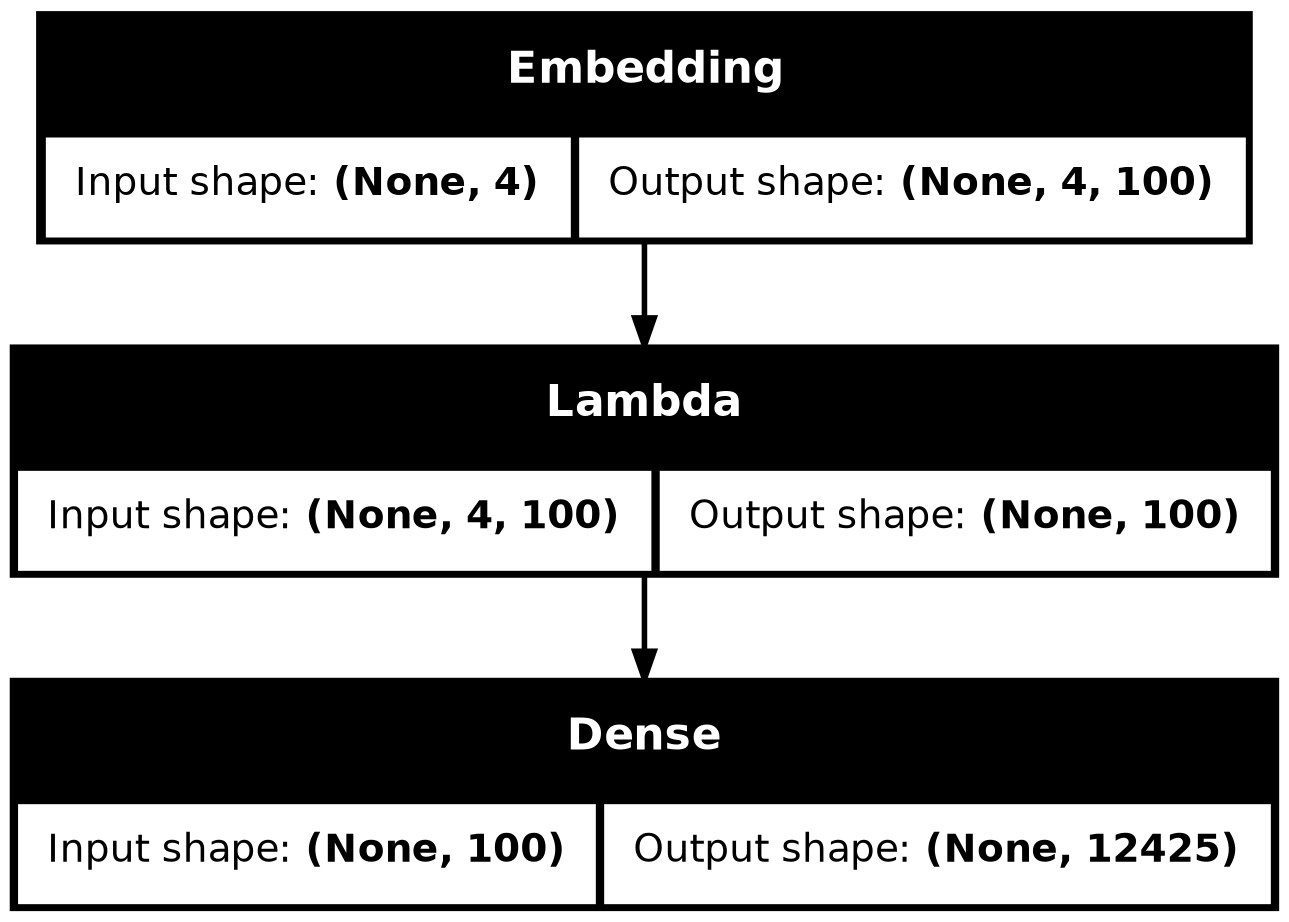

In [141]:
from tensorflow.keras.utils import plot_model

dot_img_file = 'cbow_model.png'
plot_model(cbow, to_file=dot_img_file, show_shapes=True)

### Train model for 5 epochs

In [94]:
import tensorflow as tf
with tf.device('/device:XLA:0'):
    for epoch in range(1, 6):
        loss = 0.
        i = 0
        for x, y in generate_context_word_pairs(corpus=wids, window_size=window_size, vocab_size=vocab_size):
            i += 1
            loss += cbow.train_on_batch(x, y)
            if i % 100000 == 0:
                print('Processed {} (context, word) pairs'.format(i))

        print('Epoch:', epoch, '\tLoss:', loss)
        print()

cbow.save('cbow.keras', zipped=True, overwrite=True)

Processed 100000 (context, word) pairs
Processed 200000 (context, word) pairs
Processed 300000 (context, word) pairs
Epoch: 1 	Loss: 2751313.5709700584

Processed 100000 (context, word) pairs
Processed 200000 (context, word) pairs
Processed 300000 (context, word) pairs
Epoch: 2 	Loss: 2751608.2280745506

Processed 100000 (context, word) pairs
Processed 200000 (context, word) pairs
Processed 300000 (context, word) pairs
Epoch: 3 	Loss: 2659691.095899105

Processed 100000 (context, word) pairs
Processed 200000 (context, word) pairs
Processed 300000 (context, word) pairs
Epoch: 4 	Loss: 2590056.050471306

Processed 100000 (context, word) pairs
Processed 200000 (context, word) pairs
Processed 300000 (context, word) pairs
Epoch: 5 	Loss: 2534697.7281751633



### Get word embeddings

In [97]:
from tensorflow.keras.models import load_model
cbow = load_model('cbow.keras', safe_mode=False)
weights = cbow.get_weights()[0]
weights = weights[1:]
print(weights.shape)

pd.DataFrame(weights, index=list(id2word.values())[1:]).head()

(12424, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
unto,0.635129,1.416853,0.770136,0.398571,-0.640370,-0.204701,0.649953,0.657604,1.224709,-1.186390,...,-0.817317,1.218270,0.516714,-0.749229,-1.293972,-0.896479,0.567020,0.455043,-1.032766,1.353013
lord,1.129623,0.722999,1.160678,0.829847,-0.534135,-0.851535,0.697373,0.724946,1.589080,-0.982096,...,-1.616081,0.730251,1.029526,-0.797811,-0.961351,-0.873796,0.765271,0.517478,-1.540002,0.668208
thou,1.174076,0.681800,0.768852,0.528514,-0.912481,-0.496993,0.323981,1.199727,1.545103,-0.792395,...,-1.097269,0.743369,0.884573,-0.688904,-0.316331,-1.240178,0.563388,0.584925,-0.931804,0.987888
thy,1.042604,1.354809,1.085145,0.963295,-1.281486,-1.105507,0.005268,1.107751,1.201690,-1.112518,...,-1.419057,0.133386,0.365966,-0.636368,-1.072115,-1.149498,1.121510,0.674242,-0.993133,1.486846
god,0.715969,0.853496,0.850871,0.728235,-1.137836,-0.575236,0.274543,0.779061,1.300986,-1.095119,...,-0.884338,0.746538,0.574251,-0.384931,-0.961136,-0.673654,0.612400,0.939930,-0.903859,1.101680


### Build a distance matrix to view the most similar words (contextually)

In [99]:
from sklearn.metrics.pairwise import euclidean_distances

# compute pairwise distance matrix
distance_matrix = euclidean_distances(weights)
print(distance_matrix.shape)

# view contextually similar words
similar_words = {search_term: [id2word[idx] for idx in distance_matrix[word2id[search_term]-1].argsort()[1:6]+1] 
                   for search_term in ['god', 'jesus', 'noah', 'egypt', 'john', 'gospel', 'moses','famine']}

similar_words

(12424, 12424)


{'god': ['abednego', 'lord', 'thee', 'unto', 'ye'],
 'jesus': ['meshach', 'carmelite', 'god', 'covetous', 'hath'],
 'noah': ['shema', 'tirzah', 'engannim', 'gedor', 'apollos'],
 'egypt': ['therefore', 'people', 'behold', 'even', 'disciples'],
 'john': ['many', 'lo', 'yea', 'also', 'much'],
 'gospel': ['faith', 'also', 'peace', 'people', 'god'],
 'moses': ['abednego', 'disciples', 'therefore', 'meshach', 'shadrach'],
 'famine': ['sorcerers', 'holding', 'expectation', 'strifes', 'whoremongers']}

## Implementing a word2vec model using a skip-gram neural network architecture

### Build Vocabulary

In [102]:
from tensorflow.keras.preprocessing import text

tokenizer = text.Tokenizer()
tokenizer.fit_on_texts(norm_bible)

word2id = tokenizer.word_index
id2word = {v:k for k, v in word2id.items()}

vocab_size = len(word2id) + 1 
embed_size = 100

wids = [[word2id[w] for w in text.text_to_word_sequence(doc)] for doc in norm_bible]
print('Vocabulary Size:', vocab_size)
print('Vocabulary Sample:', list(word2id.items())[:10])

Vocabulary Size: 12425
Vocabulary Sample: [('shall', 1), ('unto', 2), ('lord', 3), ('thou', 4), ('thy', 5), ('god', 6), ('ye', 7), ('said', 8), ('thee', 9), ('upon', 10)]


### Build and View sample skip grams ((word1, word2) -> relevancy)

In [104]:
from tensorflow.keras.preprocessing.sequence import skipgrams

# generate skip-grams
skip_grams = [skipgrams(wid, vocabulary_size=vocab_size, window_size=10, seed=0.5) for wid in wids]

# view sample skip-grams
pairs, labels = skip_grams[0][0], skip_grams[0][1]
for i in range(10):
    print("({:s} ({:d}), {:s} ({:d})) -> {:d}".format(
          id2word[pairs[i][0]], pairs[i][0], 
          id2word[pairs[i][1]], pairs[i][1], 
          labels[i]))

(king (13), rameses (5208)) -> 0
(bible (5766), james (1154)) -> 1
(james (1154), bible (5766)) -> 1
(bible (5766), cold (2275)) -> 0
(king (13), pate (10429)) -> 0
(king (13), james (1154)) -> 1
(king (13), bible (5766)) -> 1
(james (1154), watersprings (7784)) -> 0
(james (1154), king (13)) -> 1
(james (1154), bittern (6489)) -> 0


### Build Skip-gram Deep Network Model

In [106]:
from tensorflow.keras.layers import Dot, Dense, Reshape, Embedding, Input
from tensorflow.keras.models import Model

word_input = Input(shape=(1,))
word_emb = Embedding(vocab_size, embed_size,
                         embeddings_initializer="glorot_uniform")(word_input)
word_reshape = Reshape((embed_size, ))(word_emb)
word_model = Model(word_input, word_reshape)

context_input = Input(shape=(1,))
context_emb = Embedding(vocab_size, embed_size,
                  embeddings_initializer="glorot_uniform")(context_input)
context_reshape = Reshape((embed_size, ))(context_emb)
context_model = Model(context_input, context_reshape)

# dotlayer = Dot(axes=1,input_shape=[word_model.output, context_model.output])([word_model.output, context_model.output])
dotlayer = Dot(axes=1)([word_model.output, context_model.output])
denselayer = Dense(1, kernel_initializer="glorot_uniform", activation="sigmoid")(dotlayer)

model = Model([word_model.input,context_model.input], outputs = denselayer)
model.compile(loss="mean_squared_error", optimizer="adam", jit_compile=True)
print(model.summary())

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 100)    │  1,242,500 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 100)    │  1,242,500 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 100)       │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 100)       │          0 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_3 (Dot)         │ (None, 1)         │          0 │ reshape_6[0][0],  │
│                     │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │          2 │ dot_3[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,485,002 (9.48 MB)

 Trainable params: 2,485,002 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

None


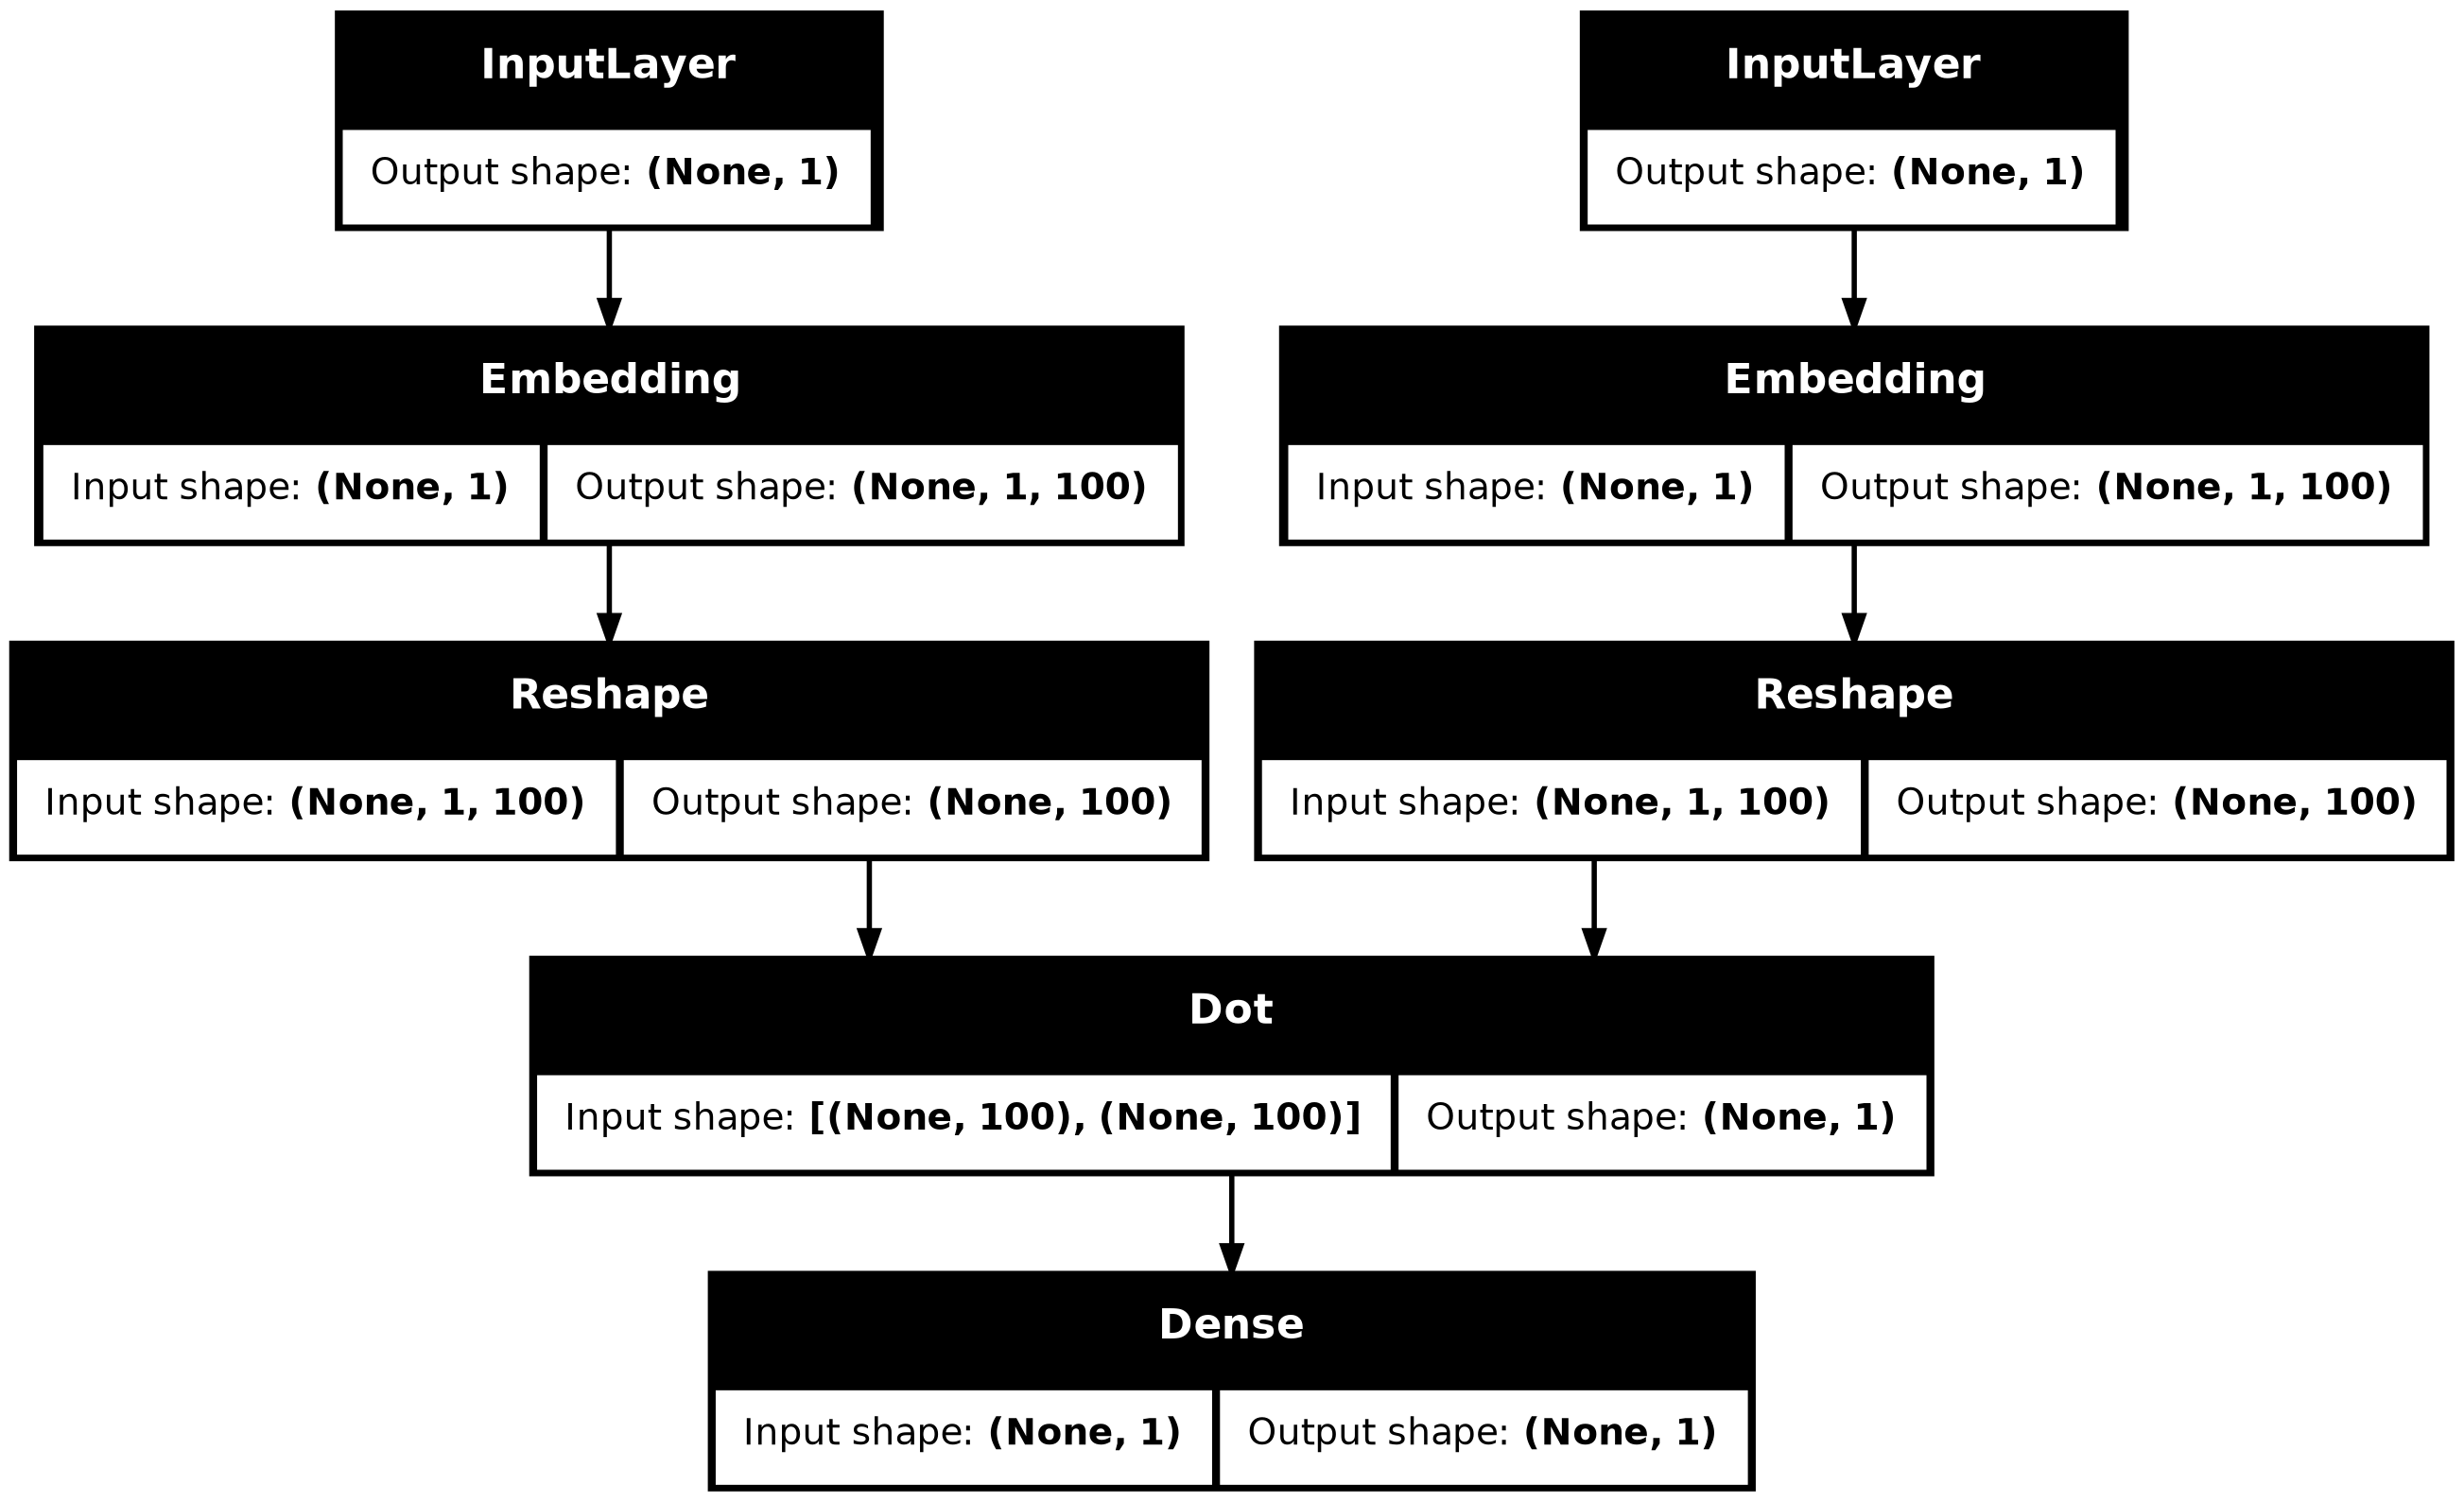

In [142]:
from tensorflow.keras.utils import plot_model

dot_img_file = 'skip_gram_model.png'
plot_model(model, to_file=dot_img_file, show_shapes=True)


In [108]:
import tensorflow as tf
with tf.device('/device:GPU:0'):
    for epoch in range(1, 6):
        loss = 0
        for i, elem in enumerate(skip_grams):
            pair_first_elem = np.array(list(zip(*elem[0]))[0], dtype='int32')
            pair_second_elem = np.array(list(zip(*elem[0]))[1], dtype='int32')
            labels = np.array(elem[1], dtype='int32')
            X = [pair_first_elem, pair_second_elem]
            Y = labels
            if i % 10000 == 0:
                print('Processed {} (skip_first, skip_second, relevance) pairs'.format(i))
            loss += model.train_on_batch(X,Y)

        print('Epoch:', epoch, 'Loss:', loss)

model.save('model.keras', overwrite=True, zipped=True)

Processed 0 (skip_first, skip_second, relevance) pairs
Processed 10000 (skip_first, skip_second, relevance) pairs
Processed 20000 (skip_first, skip_second, relevance) pairs
Epoch: 1 Loss: 1969.5761757865548
Processed 0 (skip_first, skip_second, relevance) pairs
Processed 10000 (skip_first, skip_second, relevance) pairs
Processed 20000 (skip_first, skip_second, relevance) pairs
Epoch: 2 Loss: 1534.9783172272146
Processed 0 (skip_first, skip_second, relevance) pairs
Processed 10000 (skip_first, skip_second, relevance) pairs
Processed 20000 (skip_first, skip_second, relevance) pairs
Epoch: 3 Loss: 1448.5098859108984
Processed 0 (skip_first, skip_second, relevance) pairs
Processed 10000 (skip_first, skip_second, relevance) pairs
Processed 20000 (skip_first, skip_second, relevance) pairs
Epoch: 4 Loss: 1407.7009251192212
Processed 0 (skip_first, skip_second, relevance) pairs
Processed 10000 (skip_first, skip_second, relevance) pairs
Processed 20000 (skip_first, skip_second, relevance) pairs

In [112]:
word_embed_layer = model.layers[2]
weights = word_embed_layer.get_weights()[0][1:]

print(weights.shape)
pd.DataFrame(weights, index=id2word.values()).head()

(12424, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
shall,0.016974,0.173109,0.029040,-0.637556,-0.365384,-0.071384,0.212239,0.145699,-0.146303,0.527020,...,0.139496,0.495446,0.059455,-0.306854,0.244697,0.333849,-0.149983,-0.357527,-0.054413,0.436611
unto,-0.373776,0.238671,0.132727,-0.284250,0.513444,0.287197,0.364900,0.773882,0.287646,0.079747,...,-0.258646,-0.472424,0.131946,-0.367902,0.303617,0.108489,-0.868658,-0.386265,0.681853,-0.692182
lord,-0.061370,0.781987,0.101664,-0.264612,0.216136,0.244196,-0.381493,-0.327532,-0.001120,-0.518420,...,-0.564945,-0.199318,0.170415,-0.528261,-0.053491,-0.055921,-0.450083,-0.313055,0.867277,-0.362855
thou,-0.240368,-0.041426,0.309720,-0.474516,-0.348570,0.775517,0.070521,0.956555,-0.378456,-0.103392,...,0.400678,-0.356893,-0.312435,0.279142,0.436819,0.333254,-0.016541,-0.591586,0.855004,0.503232
thy,-0.010644,0.492004,0.389344,-0.394912,-0.159704,0.500728,0.373463,-0.064815,0.321532,0.177177,...,-0.658369,-0.311399,0.085655,0.271969,0.229446,-0.037547,0.666762,-0.398850,0.361845,-0.343665


### Build a distance matrix to view the most similar words (contextually)

In [114]:
from sklearn.metrics.pairwise import euclidean_distances

distance_matrix = euclidean_distances(weights)
print(distance_matrix.shape)

similar_words = {search_term: [id2word[idx] for idx in distance_matrix[word2id[search_term]-1].argsort()[1:6]+1]
                   for search_term in ['god', 'jesus', 'noah', 'egypt', 'john', 'gospel', 'moses','famine']}

similar_words

(12424, 12424)


{'god': ['vows', 'manifested', 'suffice', 'teachers', 'stiffnecked'],
 'jesus': ['epistle', 'baptized', 'philip', 'christ', 'simon'],
 'noah': ['males', 'ater', 'jared', 'songs', 'sacks'],
 'egypt': ['egyptians', 'canaan', 'sennacherib', 'pharaoh', 'treasures'],
 'john': ['andrew', 'caiaphas', 'philip', 'pilate', 'apostle'],
 'gospel': ['revelation', 'tradition', 'evidence', 'gored', 'obedience'],
 'moses': ['jaazaniah', 'record', 'preach', 'gospel', 'sherebiah'],
 'famine': ['devourer', 'bondservice', 'whoredom', 'churl', 'alter']}

### Visualize word embeddings

Total words: 48 	Word Embedding shapes: (48, 100)


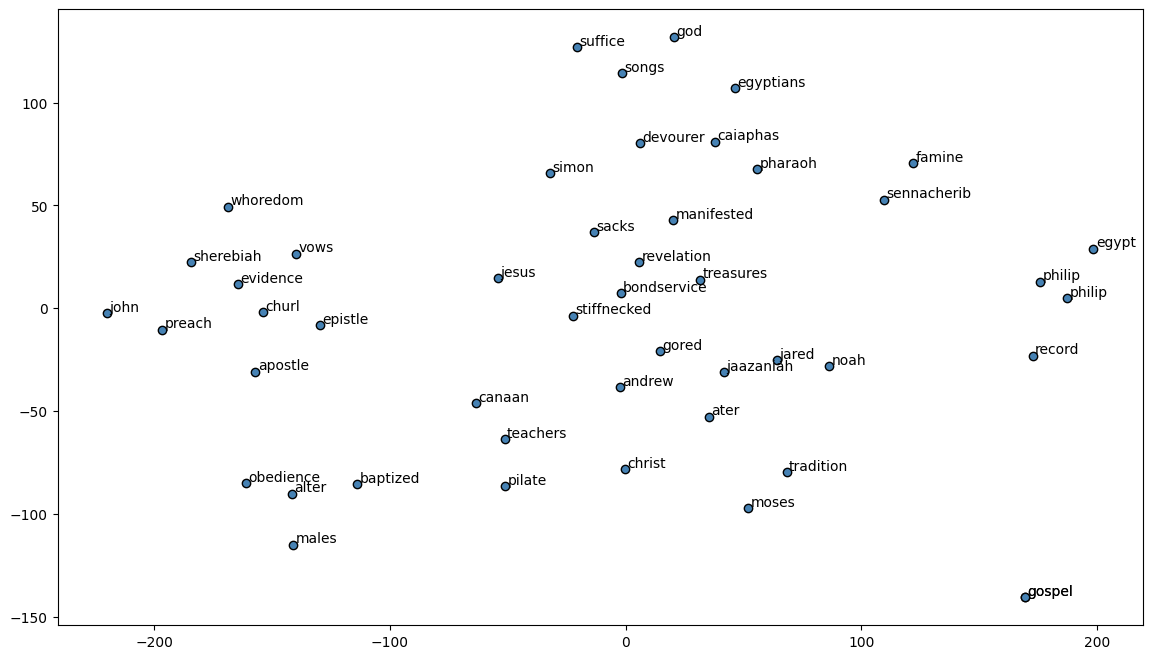

In [116]:
from sklearn.manifold import TSNE

words = sum([[k] + v for k, v in similar_words.items()], [])
words_ids = [word2id[w] for w in words]
word_vectors = np.array([weights[idx] for idx in words_ids])
print('Total words:', len(words), '\tWord Embedding shapes:', word_vectors.shape)

tsne = TSNE(n_components=2, random_state=0, n_iter_without_progress=10000, perplexity=3)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(word_vectors)
labels = words

plt.figure(figsize=(14, 8))
plt.scatter(T[:, 0], T[:, 1], c='steelblue', edgecolors='k')
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x+1, y+1), xytext=(0, 0), textcoords='offset points')

## Leveraging gensim for building a word2vec model

In [144]:
from gensim.models import word2vec

# tokenize sentences in corpus
wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(document) for document in norm_bible]

# Set values for various parameters
feature_size = 100    # Word vector dimensionality  
window_context = 30          # Context window size                                                                                    
min_word_count = 1   # Minimum word count                        
sample = 1e-3   # Downsample setting for frequent words

w2v_model = word2vec.Word2Vec(tokenized_corpus, vector_size=feature_size,
                          window=window_context, min_count=min_word_count,
                          sample=sample, epochs=50)

w2v_model.save('w2v_model.h5')

# view similar words based on gensim's model
similar_words = {search_term: [item[0] for item in w2v_model.wv.most_similar([search_term], topn=5)]
                  for search_term in ['god', 'jesus', 'noah', 'egypt', 'john', 'gospel', 'moses','famine']}
similar_words

{'god': ['worldly', 'lord', 'us', 'sworn', 'reasonable'],
 'jesus': ['messias', 'peter', 'apostles', 'immediately', 'cross'],
 'noah': ['shem', 'japheth', 'ham', 'milcah', 'kenan'],
 'egypt': ['egyptians', 'bondage', 'pharaoh', 'rod', 'rid'],
 'john': ['james', 'baptist', 'devine', 'galilee', 'peter'],
 'gospel': ['christ', 'faith', 'godly', 'afflictions', 'hope'],
 'moses': ['congregation', 'children', 'aaron', 'ordinance', 'joshua'],
 'famine': ['pestilence', 'peril', 'blasting', 'mildew', 'deaths']}

## Visualizing word embeddings

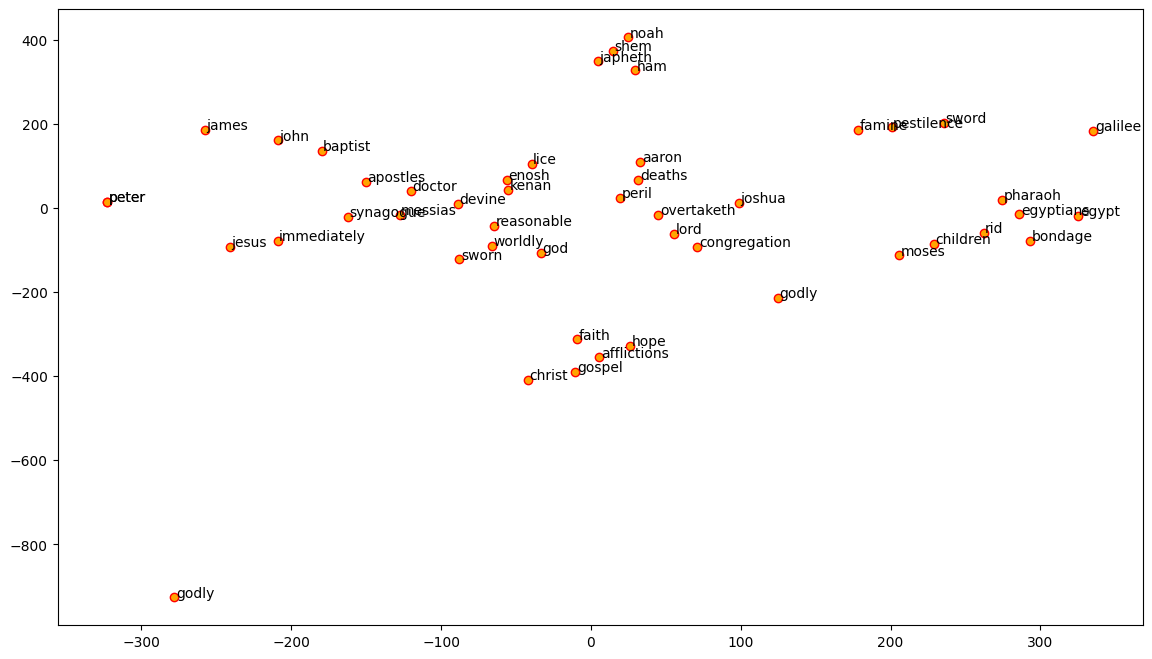

In [120]:
from sklearn.manifold import TSNE

words = sum([[k] + v for k, v in similar_words.items()], [])
wvs = w2v_model.wv[words]

tsne = TSNE(n_components=2, random_state=0, n_iter_without_progress=10000, perplexity=2)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(wvs)
labels = words

plt.figure(figsize=(14, 8))
plt.scatter(T[:, 0], T[:, 1], c='orange', edgecolors='r')
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x+1, y+1), xytext=(0, 0), textcoords='offset points')

## Applying the word2vec model on our sample corpus

In [122]:
wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(document) for document in norm_corpus]

# Set values for various parameters
feature_size = 10    # Word vector dimensionality  
window_context = 10          # Context window size                                                                                    
min_word_count = 1   # Minimum word count                        
sample = 1e-3   # Downsample setting for frequent words

w2v_model = word2vec.Word2Vec(tokenized_corpus, vector_size=feature_size,
                              window=window_context, min_count = min_word_count,
                              sample=sample, epochs=100)

## Visualize word embeddings

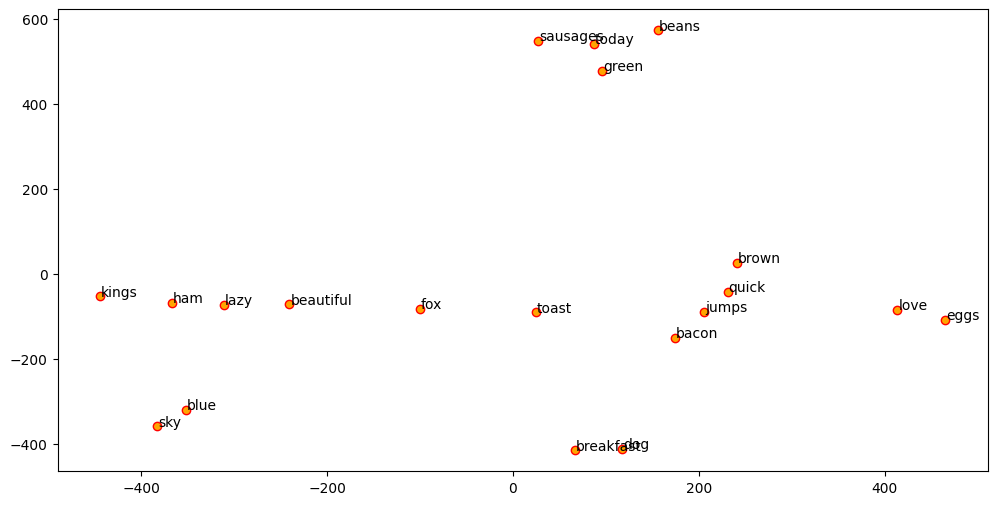

In [124]:
from sklearn.manifold import TSNE

words = w2v_model.wv.index_to_key
wvs = w2v_model.wv[words]

tsne = TSNE(n_components=2, random_state=0, n_iter_without_progress=5000, perplexity=2)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(wvs)
labels = words

plt.figure(figsize=(12, 6))
plt.scatter(T[:, 0], T[:, 1], c='orange', edgecolors='r')
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x+1, y+1), xytext=(0, 0), textcoords='offset points')

## Sample word embedding

In [126]:
w2v_model.wv['sky']

array([ 0.07402699, -0.01589274, -0.04421404,  0.06582325, -0.04710466,
       -0.0179952 ,  0.0306494 ,  0.01137792, -0.08418817, -0.09369735],
      dtype=float32)

## Build framework for getting document level embeddings

In [127]:
def average_word_vectors(words, model, vocabulary, num_features):
    
    feature_vector = np.zeros((num_features,),dtype="float64")
    nwords = 0.
    
    for word in words:
        if word in vocabulary: 
            nwords = nwords + 1.
            feature_vector = np.add(feature_vector, model[word])
    
    if nwords:
        feature_vector = np.divide(feature_vector, nwords)
        
    return feature_vector
    
   
def averaged_word_vectorizer(corpus, model, num_features):
    vocabulary = set(model.wv.index_to_key)
    features = [average_word_vectors(tokenized_sentence, model.wv, vocabulary, num_features)
                    for tokenized_sentence in corpus]
    return np.array(features)

In [128]:
w2v_feature_array = averaged_word_vectorizer(corpus=tokenized_corpus, model=w2v_model,
                                             num_features=feature_size)
pd.DataFrame(w2v_feature_array)

,0,1,2,3,4,5,6,7,8,9
0,0.041047,0.022881,-0.001678,0.021848,-0.030903,-0.027575,0.058886,0.032249,-0.054958,-0.071794
1,0.036342,0.005596,0.020427,-0.008269,-0.005434,-0.013427,0.032589,0.035600,-0.045970,-0.036483
2,-0.032684,0.020962,0.004425,-0.043295,0.016674,-0.008839,0.017254,0.011157,-0.032716,0.030807
3,-0.026415,-0.010957,0.019977,0.012114,0.032325,0.009524,0.020121,-0.010458,0.017682,0.020985
4,0.001803,-0.023276,0.015998,0.016920,0.034721,0.031532,0.014207,0.010045,-0.017303,0.028352
5,-0.035249,0.023837,0.009351,-0.014800,0.005724,-0.025017,0.019510,0.030341,-0.025415,0.017081
6,0.055035,-0.008434,-0.010093,0.033186,-0.029592,-0.003384,0.059892,0.034927,-0.051507,-0.046212
7,-0.041179,0.028253,0.000775,-0.036093,0.025078,-0.015882,0.009699,0.017987,-0.019998,0.027590


## Clustering with word embeddings

In [129]:
from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation()
ap.fit(w2v_feature_array)
cluster_labels = ap.labels_
cluster_labels = pd.DataFrame(cluster_labels, columns=['ClusterLabel'])
pd.concat([corpus_df, cluster_labels], axis=1)

,Document,Category,ClusterLabel
0,The sky is blue and beautiful.,weather,0
1,Love this blue and beautiful sky!,weather,0
2,The quick brown fox jumps over the lazy dog.,animals,2
3,"A king's breakfast has sausages, ham, bacon, eggs, toast and beans",food,1
4,"I love green eggs, ham, sausages and bacon!",food,1
5,The brown fox is quick and the blue dog is lazy!,animals,2
6,The sky is very blue and the sky is very beautiful today,weather,0
7,The dog is lazy but the brown fox is quick!,animals,2


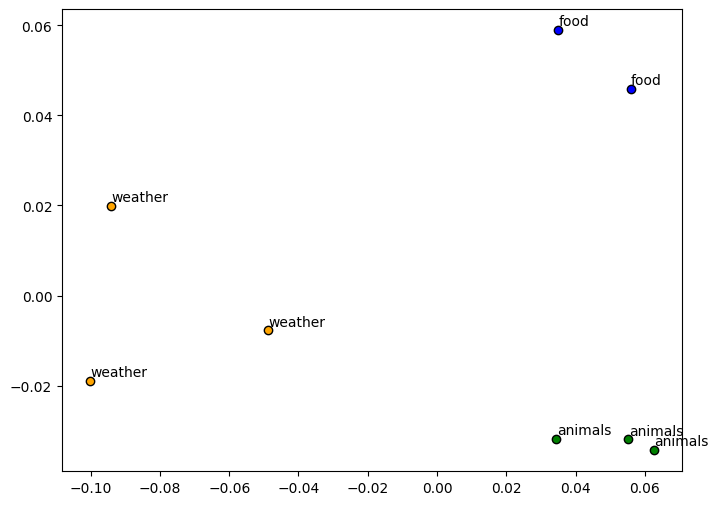

In [130]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(w2v_feature_array)
labels = ap.labels_
categories = list(corpus_df['Category'])
plt.figure(figsize=(8, 6))

for i in range(len(labels)):
    label = labels[i]
    color = 'orange' if label == 0 else 'blue' if label == 1 else 'green'
    annotation_label = categories[i]
    x, y = pcs[i]
    plt.scatter(x, y, c=color, edgecolors='k')
    plt.annotate(annotation_label, xy=(x+1e-4, y+1e-3), xytext=(0, 0), textcoords='offset points')

## GloVe Embeddings with spaCy

In [131]:
import spacy
# !python -m spacy download en_core_web_lg
nlp = spacy.load('en_core_web_lg')

total_vectors = len(nlp.vocab.vectors)
print('Total word vectors:', total_vectors)

Total word vectors: 342918


## Visualize GloVe word embeddings

In [132]:
unique_words = list(set([word for sublist in [doc.split() for doc in norm_corpus] for word in sublist]))

word_glove_vectors = np.array([nlp(word).vector for word in unique_words])
pd.DataFrame(word_glove_vectors, index=unique_words)

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
quick,-0.445630,0.191510,-0.249210,0.465900,0.161950,0.212780,-0.046480,0.021170,0.417660,1.68690,...,-0.329460,0.421860,-0.039543,0.150180,0.338220,0.049554,0.149420,-0.038789,-0.019069,0.348650
sausages,-0.174290,-0.064869,-0.046976,0.287420,-0.128150,0.647630,0.056315,-0.240440,-0.025094,0.50222,...,0.302240,0.195470,-0.653980,-0.291150,-0.684290,-0.266370,0.304310,-0.806830,0.619540,0.201200
dog,-0.401760,0.370570,0.021281,-0.341250,0.049538,0.294400,-0.173760,-0.279820,0.067622,2.16930,...,0.022908,-0.259290,-0.308620,0.001754,-0.189620,0.547890,0.311940,0.246930,0.299290,-0.074861
eggs,-0.417810,-0.035192,-0.126150,-0.215930,-0.669740,0.513250,-0.797090,-0.068611,0.634660,1.25630,...,-0.232860,-0.139740,-0.681080,-0.370920,-0.545510,0.073728,0.111620,-0.324700,0.059721,0.159160
sky,0.312550,-0.303080,0.019587,-0.354940,0.100180,-0.141530,-0.514270,0.886110,-0.530540,1.55660,...,-0.667050,0.279110,0.500970,-0.277580,-0.143720,0.342710,0.287580,0.537740,0.363490,0.496920
jumps,-0.334840,0.215990,-0.350440,-0.260020,0.411070,0.154010,-0.386110,0.206380,0.386700,1.46050,...,-0.107030,-0.279480,-0.186200,-0.543140,-0.479980,-0.284680,0.036022,0.190290,0.692290,-0.071501
beautiful,0.171200,0.534390,-0.348540,-0.097234,0.101800,-0.170860,0.295650,-0.041816,-0.516550,2.11720,...,-0.285540,0.104670,0.126310,0.120040,0.254380,0.247400,0.207670,0.172580,0.063875,0.350990
green,-0.072368,0.233200,0.137260,-0.156630,0.248440,0.349870,-0.241700,-0.091426,-0.530150,1.34130,...,-0.405170,0.243570,0.437300,-0.461520,-0.352710,0.336250,0.069899,-0.111550,0.532930,0.712680
kings,0.259230,-0.854690,0.360010,-0.642000,0.568530,-0.321420,0.173250,0.133030,-0.089720,1.52860,...,-0.470090,0.063743,-0.545210,-0.192310,-0.301020,1.068500,0.231160,-0.147330,0.662490,-0.577420
fox,-0.348680,-0.077720,0.177750,-0.094953,-0.452890,0.237790,0.209440,0.037886,0.035064,0.89901,...,-0.283050,0.270240,-0.654800,0.105300,-0.068738,-0.534750,0.061783,0.123610,-0.553700,-0.544790


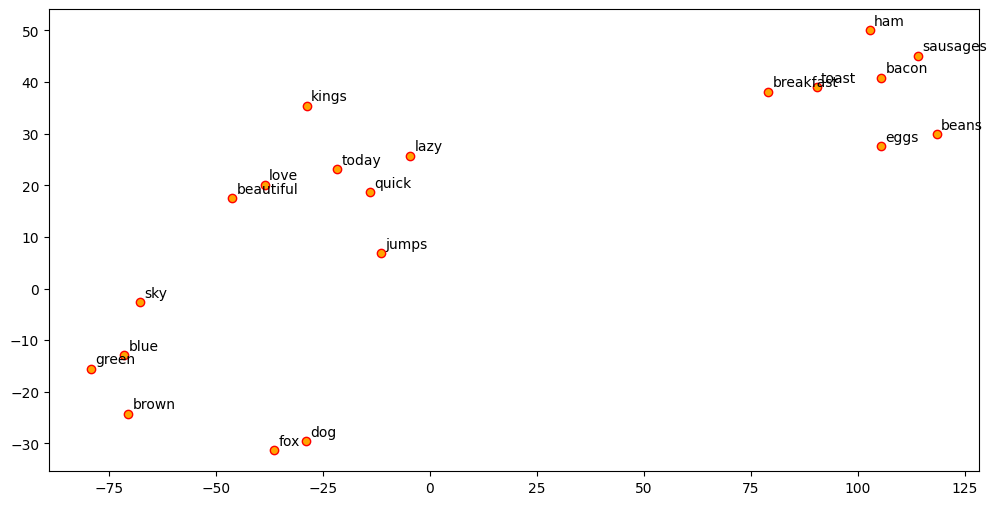

In [133]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0, n_iter_without_progress=5000, perplexity=3)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(word_glove_vectors)
labels = unique_words

plt.figure(figsize=(12, 6))
plt.scatter(T[:, 0], T[:, 1], c='orange', edgecolors='r')
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x+1, y+1), xytext=(0, 0), textcoords='offset points')

## Cluster documents with GloVe Embeddings

In [134]:
from sklearn.cluster import KMeans
doc_glove_vectors = np.array([nlp(str(doc)).vector for doc in norm_corpus])

km = KMeans(n_clusters=3, random_state=0)
km.fit_transform(doc_glove_vectors)
cluster_labels = km.labels_
cluster_labels = pd.DataFrame(cluster_labels, columns=['ClusterLabel'])
pd.concat([corpus_df, cluster_labels], axis=1)

,Document,Category,ClusterLabel
0,The sky is blue and beautiful.,weather,2
1,Love this blue and beautiful sky!,weather,2
2,The quick brown fox jumps over the lazy dog.,animals,1
3,"A king's breakfast has sausages, ham, bacon, eggs, toast and beans",food,0
4,"I love green eggs, ham, sausages and bacon!",food,0
5,The brown fox is quick and the blue dog is lazy!,animals,1
6,The sky is very blue and the sky is very beautiful today,weather,2
7,The dog is lazy but the brown fox is quick!,animals,1


# Leveraging gensim for building a FastText model

In [145]:
from gensim.models.fasttext import FastText

wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(document) for document in norm_bible]

# Set values for various parameters
feature_size = 100    # Word vector dimensionality  
window_context = 50          # Context window size                                                                                    
min_word_count = 5   # Minimum word count                        
sample = 1e-3   # Downsample setting for frequent words


ft_model = FastText(tokenized_corpus, vector_size=feature_size, window=window_context,
                    min_count=min_word_count,sample=sample, sg=1, epochs=50)

ft_model.save('ft_model.bin')


In [136]:
# view similar words based on gensim's model
similar_words = {search_term: [item[0] for item in ft_model.wv.most_similar([search_term], topn=5)]
                  for search_term in ['god', 'jesus', 'noah', 'egypt', 'john', 'gospel', 'moses','famine']}
similar_words

{'god': ['lord', 'therefore', 'unto', 'christ', 'jesus'],
 'jesus': ['christ', 'grace', 'god', 'disciples', 'faith'],
 'noah': ['methuselah', 'shem', 'creepeth', 'mahalaleel', 'adam'],
 'egypt': ['land', 'pharaoh', 'egyptians', 'shur', 'israel'],
 'john': ['baptist', 'peter', 'baptize', 'baptized', 'baptism'],
 'gospel': ['preached', 'preach', 'christ', 'preaching', 'grace'],
 'moses': ['aaron', 'commanded', 'congregation', 'spake', 'israel'],
 'famine': ['pestilence', 'sword', 'sojourn', 'dearth', 'blasting']}

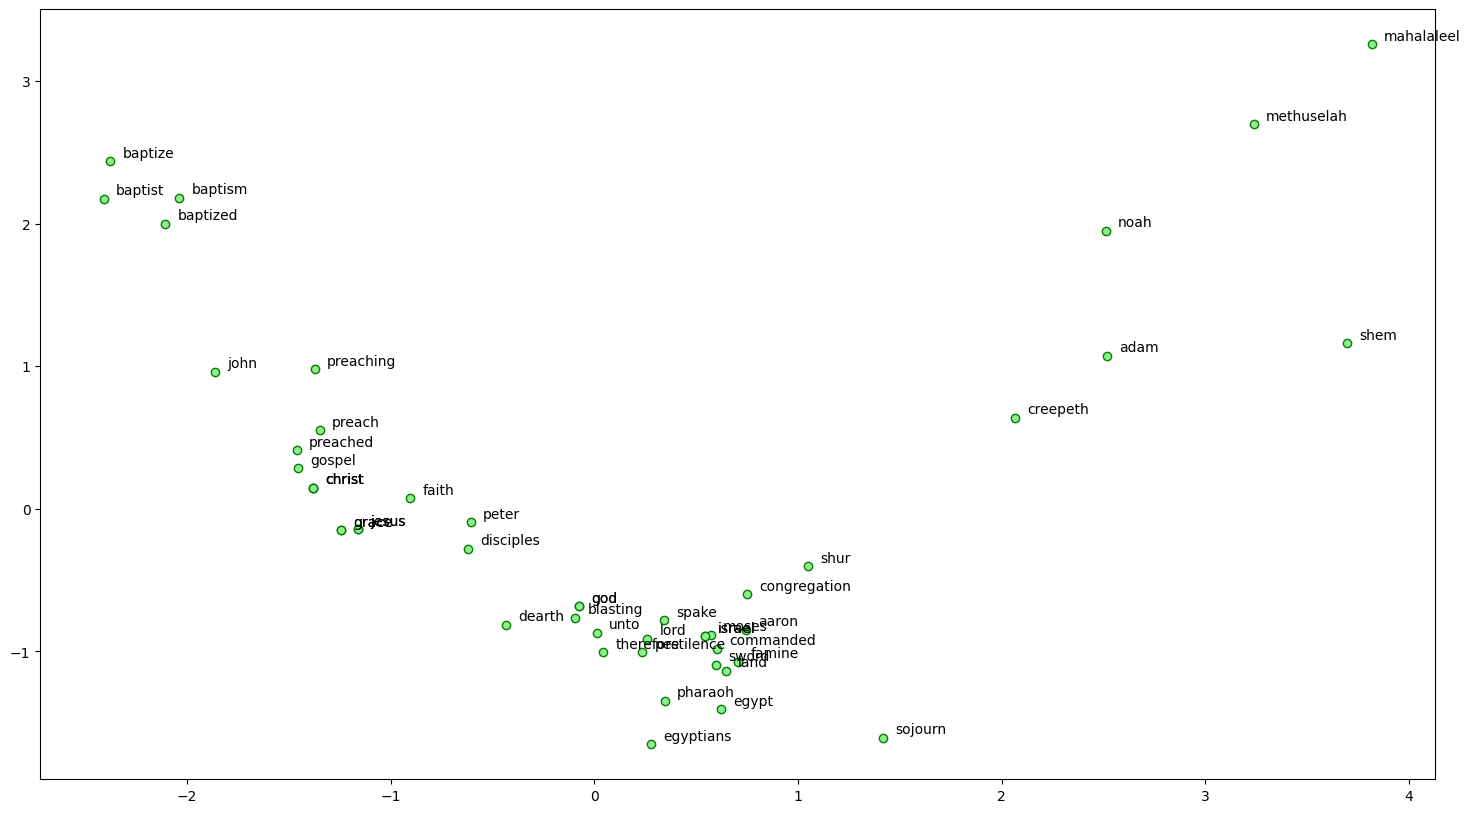

In [137]:
from sklearn.decomposition import PCA

words = sum([[k] + v for k, v in similar_words.items()], [])
wvs = ft_model.wv[words]

pca = PCA(n_components=2)
np.set_printoptions(suppress=True)
P = pca.fit_transform(wvs)
labels = words

plt.figure(figsize=(18, 10))
plt.scatter(P[:, 0], P[:, 1], c='lightgreen', edgecolors='g')
for label, x, y in zip(labels, P[:, 0], P[:, 1]):
    plt.annotate(label, xy=(x+0.06, y+0.03), xytext=(0, 0), textcoords='offset points')

In [138]:
ft_model.wv['jesus']

array([ 0.1269861 , -0.16283675, -0.05002038, -0.32045874,  0.09869288,
       -0.05071432,  0.17184493,  0.04701502,  0.02136803, -0.63103676,
       -0.2950762 , -0.07968087, -0.36497974,  0.53528047,  0.20544362,
       -0.35104427, -0.06751359, -0.46021703, -0.49144366, -0.10730419,
        0.09790169, -0.04094547, -0.0940046 , -0.26948607, -0.12583499,
       -0.25987184,  0.36917838,  0.35299283,  0.1762672 ,  0.26373455,
        0.40227777,  0.47581166,  0.05016827,  0.23534732,  0.14086862,
        0.49907267,  0.09866095,  0.15455809, -0.10711268,  0.02977571,
        0.14759241,  0.10991778,  0.10865588, -0.0375114 ,  0.4318171 ,
        0.44900876,  0.16473411,  0.22325477, -0.3291867 ,  0.08331652,
        0.27663824, -0.34854892,  0.63468635,  0.44456622,  0.19663872,
        0.05485713,  0.07584641, -0.03022041, -0.42742202, -0.25313342,
        0.08855047,  0.13993043,  0.317997  ,  0.11945035,  0.22727244,
        0.71517414, -0.21301036, -0.16807048, -0.2159114 ,  0.00

In [139]:
print(ft_model.wv.similarity(w1='god', w2='satan'))
print(ft_model.wv.similarity(w1='god', w2='jesus'))

0.36071655
0.6546278


In [140]:
st1 = "god jesus satan john"
print('Odd one out for [',st1, ']:', ft_model.wv.doesnt_match(st1.split()))

st2 = "john peter james judas"
print('Odd one out for [',st2, ']:', ft_model.wv.doesnt_match(st2.split()))

Odd one out for [ god jesus satan john ]: satan
Odd one out for [ john peter james judas ]: judas
